# LOD MLP Training Pipeline
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 16 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os



print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

In [ ]:
# -----------------------------------------
# CONFIG
# -----------------------------------------
INPUT_FILE   = '/content/drive/MyDrive/Concordia/COMP432/Project/training_data_labeled.csv'
MODEL_OUT    = '/content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx'
SCALER_OUT   = '/content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl'

FEATURE_COLS = [
    'cpu_frame_time_ms',
    'gpu_frame_time_ms',
    'triangle_count',
    'camera_velocity',
    'camera_angular_velocity',
    'visible_renderer_count',
    'draw_call_estimate',
    'frame_headroom_ms',
    'screen_coverage',
    'lod_bias_current',
]

TARGET_COL   = 'target_lod_bias'

# MLP architecture (from project docs)
HIDDEN1 = 64
HIDDEN2 = 32
HIDDEN3 = 16

# Training
BATCH_SIZE   = 512
EPOCHS  = 100
LR           = 1e-3
VAL_SPLIT    = 0.2
SEED         = 42

# LOD bias range for output denormalization
BIAS_MIN     = 0.25
BIAS_MAX     = 2.0
# -----------------------------------------

torch.manual_seed(SEED)
np.random.seed(SEED)

## 2. Load and Inspect Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print(os.path.exists('/content/drive/MyDrive/Concordia/COMP432/Project'))
print(os.listdir('/content/drive/MyDrive/Concordia/COMP432/Project'))

df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
print(f'\nTarget distribution:')
print(df[TARGET_COL].value_counts().sort_index())
print(f'\nFeature stats:')
df[FEATURE_COLS].describe().round(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
['train_lod_mlp.ipynb', 'OLD', 'OLD DATAT', 'training_data_labeled.csv']
Loaded 135000 rows, 25 columns

Target distribution:
target_lod_bias
0.647499       957
0.737777       898
0.797484       988
0.854602      2313
0.893312      2666
0.922024       571
1.019426       621
1.031023       665
1.053678       763
1.113393      1699
1.125579       568
1.146485      3062
1.147354       595
1.171710       845
1.213815      3042
1.246790       797
1.301166       762
1.331669       547
1.355317      5691
1.360982      1000
1.374672    105603
1.529353       347
Name: count, dtype: int64

Feature stats:


,cpu_frame_time_ms,gpu_frame_time_ms,triangle_count,camera_velocity,camera_angular_velocity,visible_renderer_count,draw_call_estimate,frame_headroom_ms,screen_coverage,lod_bias_current
count,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000
mean,13.746,3.770,349866.012,3.826,3.751,8727.834,2563.385,2.854,0.011,1.083
std,11.009,0.988,252013.079,3.118,14.864,7884.313,1993.887,11.009,0.011,0.717
min,1.732,1.718,50789.000,0.000,0.000,0.000,140.000,-267.686,0.000,0.250
25%,5.007,3.070,162355.250,0.500,0.000,2755.000,985.000,-2.467,0.002,0.250
50%,10.317,3.636,262998.500,3.000,0.000,5682.000,1955.000,6.283,0.006,1.000
75%,19.067,4.366,465881.000,7.999,0.000,12598.000,3615.000,11.593,0.019,2.000
max,284.286,19.076,2059145.000,8.018,266.774,32793.000,17323.000,14.868,0.064,2.000


## 3. Preprocessing

In [ ]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.3f}, {y.max():.3f}]')

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
assert os.path.exists(SCALER_OUT), f"Scaler not saved: {SCALER_OUT}"
print(f'Scaler saved to {SCALER_OUT}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

# Split remaining 80% into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Rows after dropna: 135000

Normalized target range: [0.227, 0.731]
Scaler saved to /content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl

Train: 86400 | Val: 21600 | Test: 27000


## 4. Dataset and DataLoader

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 169 | Val batches: 43


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [ ]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, hidden3=16):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2, HIDDEN3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3329


## 6. Training

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
# criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=0.3)

train_losses = []
val_losses   = []
best_val_loss = float('inf')
for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # --- validate ---
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    # early stopping check AFTER val_loss is computed
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/Concordia/COMP432/Project/best_model.pt')

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f} | LR: {current_lr:.6f}')

print('Training complete.')

# --- test ---
model.eval()
with torch.no_grad():
    X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t   = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias = test_preds.detach().cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest MSE  (normalized): {test_loss:.6f}')
print(f'Test MAE  (bias units): {test_mae:.4f}')
print(f'Test RMSE (bias units): {test_rmse:.4f}')

Epoch  10/100 | Train MSE: 0.000524 | Val MSE: 0.000557 | LR: 0.001000
Epoch  20/100 | Train MSE: 0.000467 | Val MSE: 0.000528 | LR: 0.000500
Epoch  30/100 | Train MSE: 0.000440 | Val MSE: 0.000516 | LR: 0.000125
Epoch  40/100 | Train MSE: 0.000424 | Val MSE: 0.000489 | LR: 0.000063
Epoch  50/100 | Train MSE: 0.000420 | Val MSE: 0.000489 | LR: 0.000031
Epoch  60/100 | Train MSE: 0.000417 | Val MSE: 0.000489 | LR: 0.000008
Epoch  70/100 | Train MSE: 0.000416 | Val MSE: 0.000489 | LR: 0.000004
Epoch  80/100 | Train MSE: 0.000416 | Val MSE: 0.000489 | LR: 0.000001
Epoch  90/100 | Train MSE: 0.000416 | Val MSE: 0.000489 | LR: 0.000000
Epoch 100/100 | Train MSE: 0.000416 | Val MSE: 0.000489 | LR: 0.000000
Training complete.

Test MSE  (normalized): 0.000490
Test MAE  (bias units): 0.0212
Test RMSE (bias units): 0.0548


## 7. Loss Curves

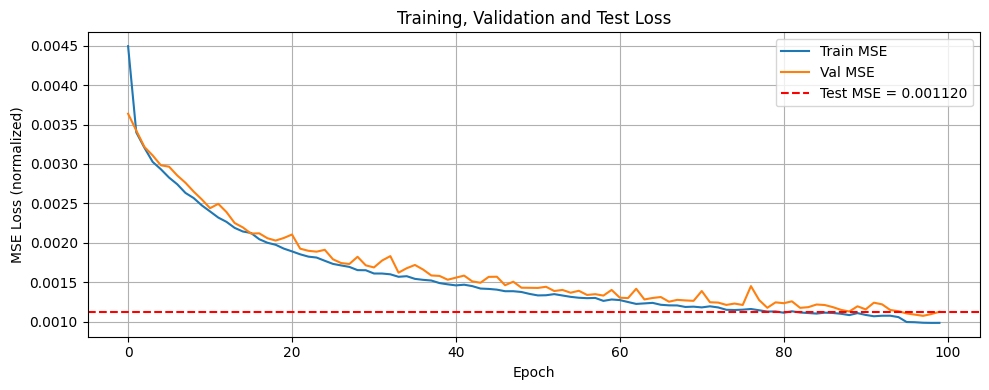

Final Train MSE : 0.000984
Final Val   MSE : 0.001124
Test        MSE : 0.001120
Test        MAE : 0.0238 (bias units)
Test        RMSE: 0.0586 (bias units)


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions



Val  MAE: 0.0238 | Val  RMSE: 0.0588
Test MAE: 0.0238 | Test RMSE: 0.0586


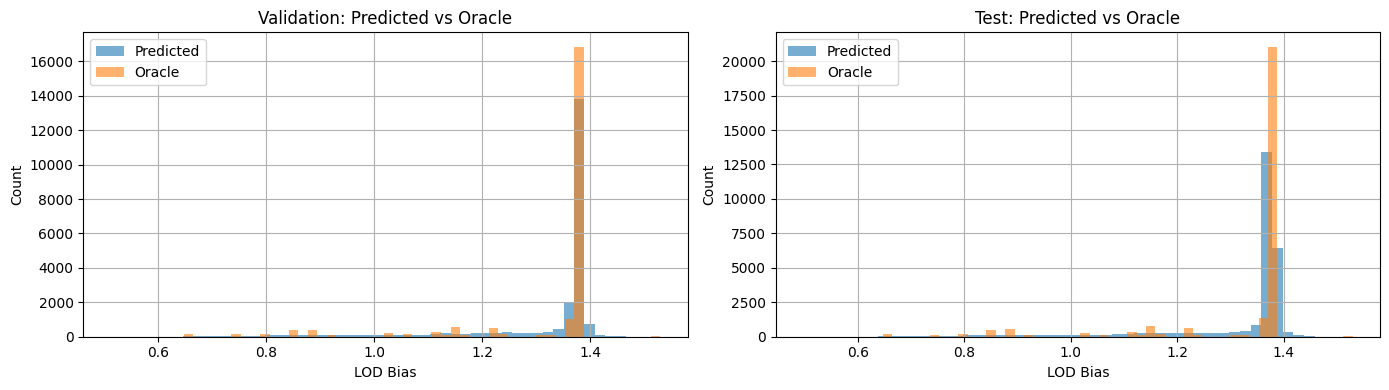

In [ ]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150)
plt.show()


## 9. Export to ONNX for Unity Sentis

In [ ]:
!pip install onnxscript onnx

In [ ]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=15,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

/tmp/ipykernel_334/438338614.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0305 05:10:53.213000 334 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model saved to /content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx (2.2 KB)
Input dim: 10 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


In [ ]:
import onnx

# Load the split model (needs both .onnx and .onnx.data in same folder)
model_onnx = onnx.load(MODEL_OUT, load_external_data=True)

# Save as single self-contained file - no external data
SINGLE_OUT = '/content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp_single.onnx'
onnx.save_model(
    model_onnx,
    SINGLE_OUT,
    save_as_external_data=False
)

import os
size_kb = os.path.getsize(SINGLE_OUT) / 1024
print(f'Saved single-file ONNX: {SINGLE_OUT} ({size_kb:.1f} KB)')

Saved single-file ONNX: /content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp_single.onnx (14.5 KB)


### 9b. Export Scaler Constants to JSON

In [ ]:
import json, joblib

scaler = joblib.load(SCALER_OUT)

constants = {
    'mean':          scaler.mean_.tolist(),
    'scale':         scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS,
    'bias_min':      BIAS_MIN,
    'bias_max':      BIAS_MAX
}

SCALER_JSON = '/content/drive/MyDrive/Concordia/COMP432/Project/scaler_constants.json'
with open(SCALER_JSON, 'w') as f:
    json.dump(constants, f, indent=2)

print(f'Saved to {SCALER_JSON}')
print(json.dumps(constants, indent=2))

Saved to /content/drive/MyDrive/Concordia/COMP432/Project/scaler_constants.json
{
  "mean": [
    13.74635723659639,
    3.770054661552994,
    349866.0124148148,
    3.8261654804284926,
    3.7511031120388596,
    8727.834133333334,
    2563.3854814814813,
    2.85364276303821,
    0.010823687427240119,
    1.0833333333333333
  ],
  "scale": [
    11.008536775133145,
    0.9880065983148854,
    252012.14573877203,
    3.11777248509249,
    14.86431885256129,
    7884.284028073361,
    1993.8791703008442,
    11.008536771157578,
    0.011215882007319176,
    0.7168604389202191
  ],
  "feature_names": [
    "cpu_frame_time_ms",
    "gpu_frame_time_ms",
    "triangle_count",
    "camera_velocity",
    "camera_angular_velocity",
    "visible_renderer_count",
    "draw_call_estimate",
    "frame_headroom_ms",
    "screen_coverage",
    "lod_bias_current"
  ],
  "bias_min": 0.25,
  "bias_max": 2.0
}


## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float predictedBias  = normalizedBias * (BIAS_MAX - BIAS_MIN) + BIAS_MIN;
// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```